# Travel Personas
- using k means to try and find the type of traveller i am on different days

Notes:
- curse of dimensionality: if i put too many features relating to one topic, the rest will be ignored in favor of the feature heavy tiopic
- consider what is important: look into PCA?
- remember kmeans if sensitive to scaling of values - use StandardScaler

### Imports

In [185]:
import pandas as pd
import numpy as np
import scipy as sp
import plotly.express as px
import plotly.graph_objects as go
import datetime

import json

from transformers import pipeline
from sentence_transformers import SentenceTransformer, util

from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


### Variables

In [102]:
hours_in_a_day = 24

In [103]:
regions = {
    'South America': ['Colombia','Ecuador','Peru','Bolivia','Brasil'],
    'Central America': ['Guatemala','Honduras','Nicaragua','El Salvador'],
    'Southern Africa': ['South Africa','Malawi','Mozambique','Eswatini','Lesotho']
}

In [104]:
base_currency = ['CAD']

In [105]:
countries = {
    'Colombia' : {
        'color': '#EFCA08',
        'currency': ['COP']
    },
    'Ecuador' : {
        'color': '#FF9000',
        'currency': ['USD']
    },
    'Peru' : {
        'color': '#DB5461',
        'currency': ['PEN']
    },
    'Bolivia' : {
        'color': '#A4243B',
        'currency': ['BOB']
    },
    'Brasil' : {
        'color': '#94BFA7',
        'currency': ['BRL']
    },
    'Guatemala' : {
        'color': '#86A5D9',
        'currency': ['GTQ','USD']
    },
    'Honduras' : {
        'color': '#0B3954',
        'currency': ['HNL','USD']
    },
    'Nicaragua' : {
        'color': '#57C4E5',
        'currency': ['NIO','USD']
    },
    'El Salvador': {
        'color': '#273043',
        'currency': ['USD']
    },
    'South Africa': {
        'color': '#D4E09B',
        'currency': ['ZAR']
    },
    'Malawi': {
        'color': '#D72638',
        'currency': ['MK','BMK']
    },
    'Mozambique': {
        'color': '#2D5C1E',
        'currency': ['MZN']
    },
    'Eswatini': {
        'color': '#AFA3B8',
        'currency': ['ZAR']
    },
    'Lesotho': {
        'color': '#8EF9F3',
        'currency': ['ZAR']
    }
}

In [287]:
transport_types = {
    'hitchhiking': {
        'values': ['hitchhiking'],
        'comfort_mapping': 1
    },
    'self': {
        'values': ['car', 'car share'],
        'comfort_mapping': 5
    },
    'bus': {
        'values': ['bus'],
        'comfort_mapping': 3
    },
    'tourist': {
        'values': ['van', 'truck', 'flight', 'teleferico', 'jeep', 'boat', 'shuttle'],
        'comfort_mapping': 4
    },
    'local': {
        'values': ['chicken bus', 'mini bus', 'chapa', 'kombi', 'collectivo', 'train'],
        'comfort_mapping': 2
    }
}

### Functions

In [107]:
def map_countries(df, timeline):
    for idx, row in timeline.iterrows():
        # get all rows that occur in the dates within a country timeline and see if the row has the currency of a country
        clip = df[(df.date >= row.entry_date) & (df.date <= row.exit_date) & (df.currency.isin(countries[row.country]['currency'] + base_currency))]
    
        df.loc[clip.index.values, 'country'] = row.country

    return df

In [108]:
# formatting columns to be nicer to work with
def format_names(df):
    for col in df.columns:
        df = df.rename(columns={col: col.replace(' ','_')})

    return df

### Base data

In [109]:
timeline = pd.read_csv('../data/country_timeline.csv')
timeline['entry_date'] = pd.to_datetime(timeline['entry_date'])#, format='%m/%d/%Y')
timeline['exit_date'] = pd.to_datetime(timeline['exit_date'])#, format='%m/%d/%Y')

In [235]:
money = pd.read_csv('../data/money_manager_2024_2025.csv')
money.columns = money.columns.str.lower()
money = money.rename(columns={'income/expense':'income_expense',' ':'date'})

In [236]:
money['date'] = pd.to_datetime(money['date'], format='%m/%d/%Y %H:%M:%S').dt.normalize()
money['month'] = money['date'].dt.strftime("%B %Y")

In [237]:
money = map_countries(money, timeline)

In [113]:
# fix two lines in money data set that need a different category
change_cat = ['Towel','Volunteer fee at the pink iguana']
money.loc[money.note.isin(change_cat), 'category'] = 'Other'

In [303]:
transport = pd.read_csv('../data/transport_data.csv')
transport = format_names(transport)
transport['date'] = pd.to_datetime(transport['date'], format='%m/%d/%Y')

# have to get rid of the random extra column i added for some reason
transport = transport.drop('Unnamed:_8', axis=1)

# fixing hitch hiking split
transport['type'] = transport['type'].str.replace('hitch hiking','hitchhiking')
transport['type'] = transport['type'].str.replace('bus ','bus')

### Making the feature vectors
- 1 day into a bunch of features
- spending:
  - ~category diversity - unique categories per day
  - ~~purchases sum for each category ?~~
  - ~~number of purchases for each category ?~~
  - ~~maybe have the average price per purchase per category ?~~
  - ~sum of dollars spent (use log transformation)
  - ~buget utilization (spending/allowance)
  - ~purchase frequency
  - ~~food to total ratio ?~~
  - ~baseline cost (cost of existing: food + accomodation)
  - ~adventure/culture intensity: sum of these two
  - ~experience ratio of cost of adventure over total spend
  - ~material signal (gifts, crafts, apparel, etc)
  
- transport:
  - ~hours spent travelling
  - ~number of different unique transports taken
  - ~transport type category comfort label
  - ~overall number of transports taken
  - ~night travel ratio
  - ~~border crossing flag?~~
  - ~transits per hour
- activities/tours:
  - activity done (will need to map this out to different days because activities are put in by date & length of time)
  - tour done (will need to map this out to different days because activities are put in by date & length of time)
  - label of activity type
  - label of tour done
  - time spent on activity
  - time spent on tour
- extra randoms
  - ~split type of accomodations into values: dorm, camping, suite, unpaid (ended up using probabilities)
- location data:
  - ~~country numerical value - dont think i want to bias by country~~
  
  
**note** remember when i bring together this data, eveything will have to match the dates available from the money data (July 2024 onward)

In [407]:
money.groupby(['category']).cad.count().reset_index()

,category,cad
0,Other,6
1,✒️ Tattoo,2
2,🌎 Adventure,180
3,🍜 Food,946
4,🎁 Gift,62
5,🏠 Accommodation,330
6,👬🏻 Social Life,85
7,💄 Beauty,34
8,📙 Education,3
9,🖼 Culture,30


## Spending Features

In [424]:
# grouping by to get dollar sum and number of times sum
money_agg = money.groupby(['date','income_expense']).agg({'cad':'sum', 'currency':'count'}).reset_index()

# pivot the table to get the categories as 
mpiv = money_agg.pivot(index='date', columns='income_expense', values=['cad','currency']).reset_index()
mpiv.columns = [col[0] if col[0] in 'date' else'_'.join(map(str, col)).strip() for col in mpiv.columns.values]

# rename columns and keep only necessary data
mpiv = mpiv.rename(columns={
    'cad_Expense':'total_expense',
    'cad_Income': 'budget',
    'currency_Expense': 'transactions_per_day'
}).drop('currency_Income', axis=1)

# get budget/spending difference
mpiv['budget_utilization'] = mpiv.total_expense / mpiv.budget

mpiv = mpiv.drop('budget', axis=1)

In [425]:
# get the unique categories purchased during the day
unique_cats = money.groupby('date').agg({'category':lambda x: len(list(set(x)))}).reset_index().rename(columns={'category':'category_count'})
mpiv = pd.merge(mpiv, unique_cats, how='outer', on='date')


In [426]:
# get the baseline cost of travelling per day: food + accomodation
baseline_cost = money[money.category.isin(['🍜 Food', '🏠 Accommodation'])].groupby('date').cad.sum().reset_index().rename(columns={'cad':'baseline_cost'})
mpiv = pd.merge(mpiv, baseline_cost, how='outer', on='date')


In [427]:
# get the adventure and culture cost
adv_culture = money[money.category.isin(['🌎 Adventure', '🖼 Culture'])].groupby('date').cad.sum().reset_index().rename(columns={'cad':'adventure_cost'})
mpiv = pd.merge(mpiv, adv_culture, how='outer', on='date')


In [447]:
# get the material purchases per day. for this join gift, apparel, crafting and select other data points
add_material_idx = [301,828,837] # some specific rows i want considered
material_cost = money[money.category.isin(['🎁 Gift','🧥 Apparel', '🧵 Crafting']) | (money.index.isin(add_material_idx))].groupby('date').note.count().reset_index().rename(columns={'note':'material_purchases'})
mpiv = pd.merge(mpiv, material_cost, how='outer', on='date')



In [449]:
# get the experience ratio of adventure cost over daily expenditure
mpiv['experience_ratio'] = mpiv.adventure_cost / mpiv.total_expense

In [451]:
# fill all the nans!
mpiv = mpiv.fillna(0)
mpiv.head()

,date,total_expense,transactions_per_day,budget_utilization,category_count,baseline_cost,adventure_cost,material_purchases,experience_ratio
0,2024-07-01,46.70,4.0,0.778333,4,32.33,0.00,0.0,0.000000
1,2024-07-02,61.44,4.0,1.024000,5,23.35,32.34,0.0,0.526367
2,2024-07-03,32.55,6.0,0.542500,5,21.70,4.93,0.0,0.151459
3,2024-07-04,27.61,4.0,0.460167,3,27.61,0.00,0.0,0.000000
4,2024-07-05,24.07,4.0,0.401167,3,24.07,0.00,0.0,0.000000


## Transport Features
- transport type: made the category more basic, but sometimes there is more than 1 type of travel... maybe add a final group that is mixed?
- completely ignore countries in this context
- update: 
    - change this to primary trasnport type (type that was used the longest) and add other feature that is boolean for ```is_multi_modal```
    - use ordinal mapping for 'comfort' for travel types
    - when the overall merge happens, need to remember that there are some no travel days that will be filled with 0

In [305]:
# invert the dictionary
type_to_category = {
    v: category 
    for category, info in transport_types.items() 
    for v in info['values']
}

# apply mapping to dataframe
transport['category'] = transport['type'].map(type_to_category)

In [327]:
transport.head()

,city,destination,region,country,date,approximate_time,type,time_of_day,category
0,Cartagena,Santa Marta,Bolivar,Colombia,2024-03-06,4.00,collectivo,day,local
1,Santa Marta,Sierra Nevada Park,Magdalena,Colombia,2024-03-08,1.00,van,day,tourist
2,Sierra Nevada Park,Tayrona Park,Magdalena,Colombia,2024-03-13,0.50,van,day,tourist
3,Tayrona Park,Santa Marta,Magdalena,Colombia,2024-03-14,0.75,bus,day,bus
4,Santa Marta,Taganga,Magdalena,Colombia,2024-03-14,0.25,collectivo,day,local


In [336]:
# get all of the transport categories that have happened in one day
f_transport = transport.groupby('date').agg({'approximate_time':'sum', 'category':'count', 'type':lambda x: list(set(x))}).reset_index()

# find if the day has had more than 1 type of transport (boolean)
f_transport['num_unique_transports'] = f_transport['type'].apply(lambda x: len(x))
f_transport = f_transport.rename(columns={'category':'total_num_transports'}).drop('type', axis=1)


In [337]:
# get the primary transport
primary_idx = transport.groupby('date').approximate_time.idxmax()
primary_trans = transport.loc[primary_idx]
primary_trans = primary_trans[['date','category']].rename(columns={'category':'primary_transport_name'})

In [365]:
# rearrange the data set a bit
transport_features = pd.merge(f_transport, primary_trans, how='inner', on='date')

transport_features.head()

,date,approximate_time,total_num_transports,num_unique_transports,primary_transport_name
0,2024-03-06,4.00,1,1,local
1,2024-03-08,1.00,1,1,tourist
2,2024-03-13,0.50,1,1,tourist
3,2024-03-14,1.00,2,2,bus
4,2024-03-16,1.75,2,2,tourist


In [366]:
# extract the mapping
category_id_map = {k: v['comfort_mapping'] for k, v in transport_types.items()}

# assign the mapping
transport_features['primary_transport'] = transport_features['primary_transport_name'].map(category_id_map)
transport_features = transport_features.drop('primary_transport_name',axis=1)

In [367]:
# add some context for travel done at night (if i suffered night buses this data will too haha)
night_day = transport.groupby(['date','time_of_day']).approximate_time.sum().reset_index()
night_day = night_day.pivot(index=['date'], columns='time_of_day', values='approximate_time').reset_index()
night_day = night_day.fillna(0)

night_day['total'] = night_day.night + night_day.day
night_day['night_travel_ratio'] = night_day.night / night_day.total

night_day.head()

time_of_day,date,day,night,total,night_travel_ratio
0,2024-03-06,4.00,0.0,4.00,0.000000
1,2024-03-08,1.00,0.0,1.00,0.000000
2,2024-03-13,0.50,0.0,0.50,0.000000
3,2024-03-14,1.00,0.0,1.00,0.000000
4,2024-03-16,0.25,1.5,1.75,0.857143


In [368]:
transport_features = pd.merge(transport_features, night_day[['date','night_travel_ratio']], how='inner', on='date')


In [371]:
transport_features['hours_per_transit'] = transport_features.approximate_time / transport_features.total_num_transports

In [372]:
transport_features.head()

,date,approximate_time,total_num_transports,num_unique_transports,primary_transport,night_travel_ratio,hours_per_transit
0,2024-03-06,4.00,1,1,2,0.000000,4.000
1,2024-03-08,1.00,1,1,4,0.000000,1.000
2,2024-03-13,0.50,1,1,4,0.000000,0.500
3,2024-03-14,1.00,2,2,3,0.000000,0.500
4,2024-03-16,1.75,2,2,4,0.857143,0.875


#### Activities/Tours Features

## Accomodation Features

In [247]:
money[money.category == '🏠 Accommodation'].head()

,date,account,category,subcategory,note,cad,income_expense,description,amount,currency,account.1,month,country
36,2025-09-16,Card,🏠 Accommodation,NaN,Forever resort campsite,12.63,Expense,NaN,170.0,ZAR,12.63,September 2025,South Africa
42,2025-09-15,Card,🏠 Accommodation,NaN,Semonkong campsite,13.38,Expense,NaN,180.0,ZAR,13.38,September 2025,Lesotho
44,2025-09-14,Card,🏠 Accommodation,NaN,Semonkong campsite,13.38,Expense,NaN,180.0,ZAR,13.38,September 2025,Lesotho
52,2025-09-13,Card,🏠 Accommodation,NaN,Sani pass dorm,11.15,Expense,NaN,150.0,ZAR,11.15,September 2025,Lesotho
56,2025-09-12,Cash,🏠 Accommodation,NaN,Mamohase Dorm,11.15,Expense,NaN,150.0,ZAR,11.15,September 2025,Lesotho


In [248]:
# unpaid accomodation is anytime we have a day that has an allowance, but has no accomodation expense
# get the days that allowance is paid out (travel days) and accom days
# find days without accomodation -- unpaid
travel_days = money[(money.category == '🤑 Allowance') & (money.note.isna())][['date']]
accom_days = money[money.category == '🏠 Accommodation'][['date','note','cad']]

accom = pd.merge(travel_days, accom_days, how='left', on='date')

# label the unpaid accom days
accom.loc[accom.note.isna() & accom.cad.isna(), 'accomodation_type'] = 'unpaid'

#### Zero Shot Classifier
- identifying type of accomodation: dorm, camping, suite

In [249]:
def get_zero_shot_data(text):

    res = classifier(text, candidate_labels)
    
    # Returning both the label and the score (confidence)
    return pd.Series([res['labels'][0], res['scores'][0]])

In [250]:
def refined_classify(text, model_label):
    keywords = ['tent', 'hammock', 'campsite', 'pitch', 'hut']
    if any(word in text.lower() for word in keywords):
        return 'camping'
    return model_label

In [251]:
# Load the classifier (this will download a pre-trained model)
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

In [252]:
candidate_labels = ['dorm', 'camping', 'suite']

In [253]:
paid_only = accom[accom.accomodation_type != 'unpaid']

In [254]:
paid_only[['predicted_label', 'confidence']] = paid_only['note'].apply(get_zero_shot_data)

In [255]:
# looked manually and found the incorrect predictions
incorrectly_labelled = [
    'Underwater explorer safari tent',
    'Coral diving tent','Hostel hammock','Tent', 'Mulanje hut'
]

In [256]:
# but we can see the zero shot still had quite high confidence in the labels
print ('zero shot classification had a correct rate of {}'.format(
    np.round(paid_only[~paid_only.note.isin(incorrectly_labelled)].shape[0]/paid_only.shape[0]*100,2)))

zero shot classification had a correct rate of 96.97


In [257]:
paid_only[paid_only.note.isin(incorrectly_labelled)]

,date,note,cad,accomodation_type,predicted_label,confidence
24,2025-09-01,Underwater explorer safari tent,12.93,NaN,suite,0.884392
25,2025-08-31,Underwater explorer safari tent,12.93,NaN,suite,0.884392
71,2025-07-17,Mulanje hut,0.79,NaN,dorm,0.720197
72,2025-07-16,Mulanje hut,0.79,NaN,dorm,0.720197
98,2025-06-21,Coral diving tent,23.41,NaN,suite,0.815324
99,2025-06-20,Coral diving tent,23.41,NaN,suite,0.815324
100,2025-06-19,Coral diving tent,23.41,NaN,suite,0.815324
101,2025-06-18,Coral diving tent,23.41,NaN,suite,0.815324
193,2025-03-19,Hostel hammock,8.66,NaN,dorm,0.838956
372,2024-08-25,Tent,17.57,NaN,dorm,0.799796


Most of the zero-shot is correct, it is just failing in a specific aspect:
<br>
**camping**
<br>
Lets do keyword augmented correction for this known problem

In [258]:
#Perform the key word augmentation
paid_only['refined_label'] = paid_only.apply(
    lambda row: refined_classify(row['note'], row['predicted_label']), 
    axis=1
)

#### Vectorize the accomodation type knowledge

In [259]:
# Step 1: generate embeddings of the accomodation description
model = SentenceTransformer('all-MiniLM-L6-v2')

# This creates a (327, 384) numpy array
embeddings = model.encode(paid_only['note'].tolist(), show_progress_bar=True)

Batches: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:00<00:00, 11.45it/s]


In [260]:
# Step 2: encode 3 labels and prepare xy
le = LabelEncoder()
y = le.fit_transform(paid_only['refined_label']) 

# X is the embeddings matrix
X = embeddings

In [261]:
# Step 3: split into test/train and train logisitic regression classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the classifier
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

print(f"Validation Accuracy: {clf.score(X_test, y_test):.2%}")

Validation Accuracy: 100.00%


#### Visualizing with t-SNE
- we are looking for neighbourhoods - clumping of our labels into defined groups
- distances dont matter and axes have no meaning

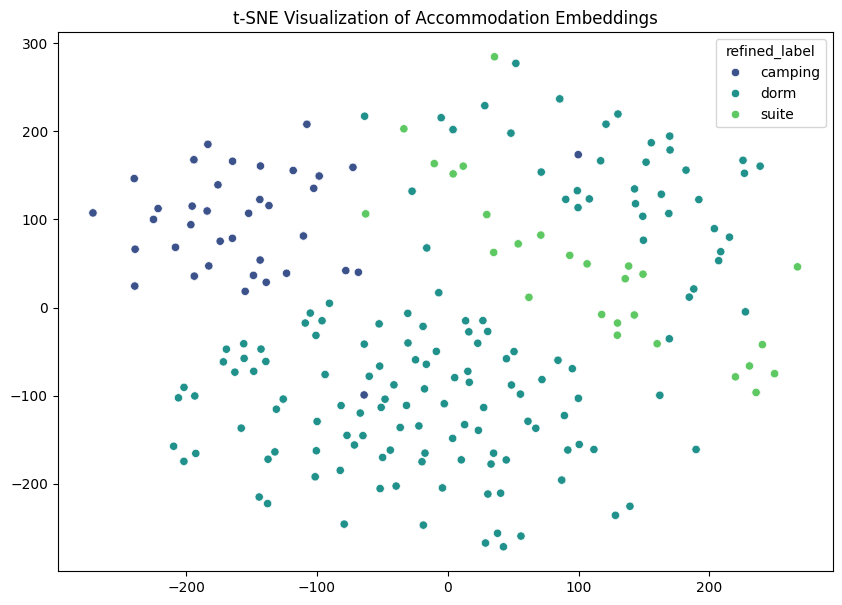

In [262]:
# perplexity is the most important hyperparameter (try between 5 and 50)
tsne = TSNE(n_components=2, perplexity=20, random_state=42, init='pca', learning_rate='auto')

# 2. Fit and transform your 384-dim embeddings into 2-dim coordinates
X_embedded = tsne.fit_transform(embeddings)

# 3. Plotting with Seaborn
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_embedded[:, 0], 
    y=X_embedded[:, 1], 
    hue=paid_only['refined_label'],  # Color by your labels (camping, dorm, etc.)
    palette='viridis',
    legend='full'
)
plt.title("t-SNE Visualization of Accommodation Embeddings")
plt.show()

Looking at this it actually makes sense to me.
- dorm has 2 different clumps. i wouldn't be surprised if this was because often dorm is defined by the use of a word like 'hostel' vs. a word like 'dorm'. dorm is like a common default - but also makes sense as most of the data points exist in dorm as this is often what my accomodation was
- suite is less of a clump and more of a line, maybe because there is more of a diversity in what helps define 'suite'. it is more of a vague description of anything that is private - from a private room, to a suite with a kitchen, to a casita
- camping is grouped pretty well. i would think this is a relatively simple grouping as its normally broken down by the words: camping, tent, hammock. its got distinctive descriptors
- further note: the camping outlier located in the dorm space: 'hostel hammock' (idx 134) which gives reason to using the probabilities in the place of the basic classification

In [263]:
# Train a model on all of the data
le = LabelEncoder()
y = le.fit_transform(paid_only['refined_label']) 
X = embeddings

clf = LogisticRegression(max_iter=1000)
clf.fit(X, y)

print(f"Model trained on {len(X)} points across {len(le.classes_)} categories.")

Model trained on 330 points across 3 categories.


In [264]:
# get the probabilities for each of the days accomodations and put in a dataframe
probabilities = clf.predict_proba(X)
prob_cols = [f"prob_{label}" for label in le.classes_]
paid_only_probs = pd.DataFrame(probabilities, columns=prob_cols)

In [265]:
paid_only_probs.head()

,prob_camping,prob_dorm,prob_suite
0,0.771782,0.140030,0.088188
1,0.829526,0.103813,0.066661
2,0.829526,0.103813,0.066661
3,0.020658,0.892083,0.087258
4,0.033246,0.914060,0.052694


In [266]:
paid_only_probs.columns

Index(['prob_camping', 'prob_dorm', 'prob_suite'], dtype='str')

In [267]:
paid_only_feature = pd.concat([paid_only.reset_index(drop=True), paid_only_probs], axis=1)

Initially i thought that the feature from this would be a single feature with the classification of ```[camping, dorm, suite, unpaid]```. but rather i will be using the classification probabilities of all of the labels to get a more all around feature set

**put all the data together for accomodation**

In [268]:
paid_only_feature.head()

,date,note,cad,accomodation_type,predicted_label,confidence,refined_label,prob_camping,prob_dorm,prob_suite
0,2025-09-16,Forever resort campsite,12.63,NaN,camping,0.968440,camping,0.771782,0.140030,0.088188
1,2025-09-15,Semonkong campsite,13.38,NaN,camping,0.954754,camping,0.829526,0.103813,0.066661
2,2025-09-14,Semonkong campsite,13.38,NaN,camping,0.954754,camping,0.829526,0.103813,0.066661
3,2025-09-13,Sani pass dorm,11.15,NaN,dorm,0.980349,dorm,0.020658,0.892083,0.087258
4,2025-09-12,Mamohase Dorm,11.15,NaN,dorm,0.963414,dorm,0.033246,0.914060,0.052694


In [269]:
paid_only_feature = paid_only_feature[['date','note','refined_label','prob_camping', 'prob_dorm', 'prob_suite']].rename(columns={'refined_label':'accomodation_type'})
paid_only_feature.loc[:,'prob_unpaid'] = 0.0

In [270]:
# update the format of unpaid to match the format of paid
unpaid_only = accom[accom.accomodation_type == 'unpaid']

for col in paid_only_probs.columns:
    unpaid_only.loc[:,col] = 0.0

# make prob_unpaid the only column with a non zero prob value
unpaid_only.loc[:, 'prob_unpaid'] = 1.0    

unpaid_only.head()

,date,note,cad,accomodation_type,prob_camping,prob_dorm,prob_suite,prob_unpaid
0,2025-09-25,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
1,2025-09-24,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
2,2025-09-23,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
3,2025-09-22,NaN,NaN,unpaid,0.0,0.0,0.0,1.0
4,2025-09-21,NaN,NaN,unpaid,0.0,0.0,0.0,1.0


In [273]:
# concat the two data frames and sort
accom_feature = pd.concat([
    paid_only_feature[['date','prob_camping', 'prob_dorm', 'prob_suite','prob_unpaid']], 
    unpaid_only[['date','prob_camping', 'prob_dorm', 'prob_suite','prob_unpaid']]
]).sort_values(by='date', ascending=True)
accom_feature.head()

,date,prob_camping,prob_dorm,prob_suite,prob_unpaid
329,2024-07-01,0.036296,0.906929,0.056775,0.0
328,2024-07-02,0.009779,0.976386,0.013834,0.0
327,2024-07-03,0.023796,0.933745,0.042459,0.0
326,2024-07-04,0.023796,0.933745,0.042459,0.0
325,2024-07-05,0.023796,0.933745,0.042459,0.0
